In [338]:
# Import packages
import scipy
import anndata
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import TruncatedSVD
from scipy import sparse, io
import seaborn as sns

matplotlib.rcParams.update({'font.size': 12})
%config InlineBackend.figure_format = 'retina'


In [339]:

dir_IlluminaO = '1213_b01_diane/b01_next1_13G_single_cell_k31_randO_mm39/counts_unfiltered/cells_x_genes'

#dir_IlluminaO = 'b01_next1_13G_single_cell_randO'
Oadata = sc.read_mtx(dir_IlluminaO+".mtx")
Oadata.obs.index = pd.read_csv(dir_IlluminaO+".barcodes.txt", header=None)[0].values
Oadata.var.index = pd.read_csv(dir_IlluminaO+".genes.txt", header=None)[0].values

dir_IlluminaT = '1213_b01_diane/b01_next1_13G_single_cell_k31_polyT_mm39/counts_unfiltered/cells_x_genes'

#dir_IlluminaT = 'b01_next1_13G_single_cell_polyT'
Tadata = sc.read_mtx(dir_IlluminaT+".mtx")
Tadata.obs.index = pd.read_csv(dir_IlluminaT+".barcodes.txt", header=None)[0].values
Tadata.var.index = pd.read_csv(dir_IlluminaT+".genes.txt", header=None)[0].values
'''
###Uncomment here to run ONT randO vs polyT comparison 

dir_ONTO = 'b01_nanopore_13G_sc_rt_randO_single_cell'
Oadata = sc.read_mtx(dir_IlluminaO+"/gcount.mtx")
Oadata.obs.index = pd.read_csv(dir_IlluminaO+"/gcount.barcodes.txt", header=None)[0].values
Oadata.var.index = pd.read_csv(dir_IlluminaO+"/gcount.genes.txt", header=None)[0].values

dir_ONTT = 'b01_nanopore_13G_sc_rt_polyT_single_cell'
Tadata = sc.read_mtx(dir_ONTT+"/gcount.mtx")
Tadata.obs.index = pd.read_csv(dir_ONTT+"/gcount.barcodes.txt", header=None)[0].values
Tadata.var.index = pd.read_csv(dir_ONTT+"/gcount.genes.txt", header=None)[0].values
'''

'\n###Uncomment here to run ONT randO vs polyT comparison \n\ndir_ONTO = \'b01_nanopore_13G_sc_rt_randO_single_cell\'\nOadata = sc.read_mtx(dir_IlluminaO+"/gcount.mtx")\nOadata.obs.index = pd.read_csv(dir_IlluminaO+"/gcount.barcodes.txt", header=None)[0].values\nOadata.var.index = pd.read_csv(dir_IlluminaO+"/gcount.genes.txt", header=None)[0].values\n\ndir_ONTT = \'b01_nanopore_13G_sc_rt_polyT_single_cell\'\nTadata = sc.read_mtx(dir_ONTT+"/gcount.mtx")\nTadata.obs.index = pd.read_csv(dir_ONTT+"/gcount.barcodes.txt", header=None)[0].values\nTadata.var.index = pd.read_csv(dir_ONTT+"/gcount.genes.txt", header=None)[0].values\n'

In [340]:
Oadata
Tadata

AnnData object with n_obs × n_vars = 10641 × 56953

In [341]:
#Tadata.obs.index=[t[16:24]+t[8:16]+t[0:8] for t in Tadata.obs.index]
#Oadata.obs.index=[t[16:24]+t[8:16]+t[0:8] for t in Oadata.obs.index]

In [342]:
import os
barcodes_prefix_path = os.path.join(dir_IlluminaO+'.barcodes.txt')
# add barcode prefix
with open(barcodes_prefix_path) as f:
    print("opening")
    bc_prefix = f.read().splitlines()
Oadata.obs["barcode"] = Oadata.obs.index.values
Oadata.obs["libcode"] = bc_prefix
Oadata.obs["iden_bc"] = Oadata.obs.index.str[16:24]
Oadata.obs["barcode_idx"] = Oadata.obs["libcode"] + Oadata.obs["barcode"]
Oadata.obs.index = Oadata.obs["barcode_idx"]
# load in metadata
meta_path="plate01.txt"
metadata = pd.read_csv(meta_path,sep='\t', header=0)
# create well to barcode from metadata
wells_x_2 = list(metadata['well'])*2
sequence = list(metadata['t_bc']) + list(metadata['r_bc'])
barcode_type = ['T']*96 + ['R']*96
bc2well = pd.DataFrame({'well' : wells_x_2, 'sequence' : sequence, 'type' : barcode_type})
# add metadata to adata obs
Oadata.obs = Oadata.obs.merge(bc2well, left_on="iden_bc", right_on="sequence", how="left").set_index("barcode_idx", drop=False)
# add tissue, sex, strain metadata
# metadata_no_bc = metadata.drop([‘t_bc’,‘r_bc’],axis = 1)
Oadata.obs = Oadata.obs.merge(metadata,
                            left_on="well",
                            right_on="well",
                            how="left").set_index("barcode_idx", drop=False)
Oadata.obs["cell_identity"] = Oadata.obs.index.str[0:16] + '-' + Oadata.obs.well
Oadata.obs.index = Oadata.obs["cell_identity"]

opening


In [343]:
import os
barcodes_prefix_path = os.path.join(dir_IlluminaT+'.barcodes.txt')
# add barcode prefix
with open(barcodes_prefix_path) as f:
    print("opening")
    bc_prefix = f.read().splitlines()
Tadata.obs["barcode"] = Tadata.obs.index.values
Tadata.obs["libcode"] = bc_prefix
Tadata.obs["iden_bc"] = Tadata.obs.index.str[16:24]
Tadata.obs["barcode_idx"] = Tadata.obs["libcode"] + Tadata.obs["barcode"]
Tadata.obs.index = Tadata.obs["barcode_idx"]
# load in metadata
meta_path="plate01.txt"
metadata = pd.read_csv(meta_path,sep='\t', header=0)
# create well to barcode from metadata
wells_x_2 = list(metadata['well'])*2
sequence = list(metadata['t_bc']) + list(metadata['r_bc'])
barcode_type = ['T']*96 + ['R']*96
bc2well = pd.DataFrame({'well' : wells_x_2, 'sequence' : sequence, 'type' : barcode_type})
print(bc2well)
# add metadata to adata obs
Tadata.obs = Tadata.obs.merge(bc2well, left_on="iden_bc", right_on="sequence", how="left").set_index("barcode_idx", drop=False)
# add tissue, sex, strain metadata
# metadata_no_bc = metadata.drop([‘t_bc’,‘r_bc’],axis = 1)
Tadata.obs = Tadata.obs.merge(metadata,
                            left_on="well",
                            right_on="well",
                            how="left").set_index("barcode_idx", drop=False)
Tadata.obs["cell_identity"] = Tadata.obs.index.str[0:16] + '-' + Tadata.obs.well
Tadata.obs.index = Tadata.obs["cell_identity"]

opening
    well  sequence type
0     A1  CATTCCTA    T
1     A2  CTTCATCA    T
2     A3  CCTATATC    T
3     A4  ACATTTAC    T
4     A5  ACTTAGCT    T
..   ...       ...  ...
187   H8  GTGTGTGT    R
188   H9  TATGCTTC    R
189  H10  ATGGTGTT    R
190  H11  GAATAATG    R
191  H12  CCTCTGTG    R

[192 rows x 3 columns]


In [344]:
Oadata.var

""
ENSMUSG00000102693.2
ENSMUSG00000064842.3
ENSMUSG00000051951.6
ENSMUSG00000102851.2
ENSMUSG00000103377.2
...
ENSMUSG00000095366.3
ENSMUSG00000095134.3
ENSMUSG00000096768.9
ENSMUSG00000099871.2


In [345]:
Tadata.var

Tadata.obs

,barcode,libcode,iden_bc,barcode_idx,well,sequence,type,t_bc,r_bc,sex,rep,strain,sample,cell_identity
cell_identity,,,,,,,,,,,,,,
AAACATCGAACAACCA-B1,AAACATCGAACAACCAATTTGGCA,AAACATCGAACAACCAATTTGGCA,ATTTGGCA,AAACATCGAACAACCAATTTGGCAAAACATCGAACAACCAATTTGGCA,B1,ATTTGGCA,T,ATTTGGCA,TATGTGTC,F,1,NODShiLtJ,CortexHippocampus,AAACATCGAACAACCA-B1
AAACATCGAACTCACC-C2,AAACATCGAACTCACCTCATTGCA,AAACATCGAACTCACCTCATTGCA,TCATTGCA,AAACATCGAACTCACCTCATTGCAAAACATCGAACTCACCTCATTGCA,C2,TCATTGCA,T,TCATTGCA,TAGTTTCC,M,1,AJ,CortexHippocampus,AAACATCGAACTCACC-C2
AAACATCGAACTCACC-C9,AAACATCGAACTCACCTCTCATGC,AAACATCGAACTCACCTCTCATGC,TCTCATGC,AAACATCGAACTCACCTCTCATGCAAACATCGAACTCACCTCTCATGC,C9,TCTCATGC,T,TCTCATGC,CCATCTTG,F,1,AJ/PWKPhJ,Heart,AAACATCGAACTCACC-C9
AAACATCGAAGAGATC-C2,AAACATCGAAGAGATCTCATTGCA,AAACATCGAAGAGATCTCATTGCA,TCATTGCA,AAACATCGAAGAGATCTCATTGCAAAACATCGAAGAGATCTCATTGCA,C2,TCATTGCA,T,TCATTGCA,TAGTTTCC,M,1,AJ,CortexHippocampus,AAACATCGAAGAGATC-C2
AAACATCGAAGGACAC-A4,AAACATCGAAGGACACACATTTAC,AAACATCGAAGGACACACATTTAC,ACATTTAC,AAACATCGAAGGACACACATTTACAAACATCGAAGGACACACATTTAC,A4,ACATTTAC,T,ACATTTAC,GCTTATAG,M,2,C57BL6NJ,CortexHippocampus,AAACATCGAAGGACAC-A4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCACGCATCTTCACA-D9,TTCACGCATCTTCACAGCTATCAT,TTCACGCATCTTCACAGCTATCAT,GCTATCAT,TTCACGCATCTTCACAGCTATCATTTCACGCATCTTCACAGCTATCAT,D9,GCTATCAT,T,GCTATCAT,GTGCTTGA,F,3,AJ/PWKPhJ,Heart,TTCACGCATCTTCACA-D9
TTCACGCATCTTCACA-B2,TTCACGCATCTTCACATTATTCTG,TTCACGCATCTTCACATTATTCTG,TTATTCTG,TTCACGCATCTTCACATTATTCTGTTCACGCATCTTCACATTATTCTG,B2,TTATTCTG,T,TTATTCTG,CAATTCTC,M,1,NODShiLtJ,CortexHippocampus,TTCACGCATCTTCACA-B2
TTCACGCATGAAGAGA-C10,TTCACGCATGAAGAGAATCCTTAC,TTCACGCATGAAGAGAATCCTTAC,ATCCTTAC,TTCACGCATGAAGAGAATCCTTACTTCACGCATGAAGAGAATCCTTAC,C10,ATCCTTAC,T,ATCCTTAC,TACTGTCT,M,1,AJ/PWKPhJ,Heart,TTCACGCATGAAGAGA-C10


In [346]:
        Oadata.obs

,barcode,libcode,iden_bc,barcode_idx,well,sequence,type,t_bc,r_bc,sex,rep,strain,sample,cell_identity
cell_identity,,,,,,,,,,,,,,
AAACATCGAACAACCA-B1,AAACATCGAACAACCATATGTGTC,AAACATCGAACAACCATATGTGTC,TATGTGTC,AAACATCGAACAACCATATGTGTCAAACATCGAACAACCATATGTGTC,B1,TATGTGTC,R,ATTTGGCA,TATGTGTC,F,1,NODShiLtJ,CortexHippocampus,AAACATCGAACAACCA-B1
AAACATCGAACTCACC-C9,AAACATCGAACTCACCCCATCTTG,AAACATCGAACTCACCCCATCTTG,CCATCTTG,AAACATCGAACTCACCCCATCTTGAAACATCGAACTCACCCCATCTTG,C9,CCATCTTG,R,TCTCATGC,CCATCTTG,F,1,AJ/PWKPhJ,Heart,AAACATCGAACTCACC-C9
AAACATCGAACTCACC-C2,AAACATCGAACTCACCTAGTTTCC,AAACATCGAACTCACCTAGTTTCC,TAGTTTCC,AAACATCGAACTCACCTAGTTTCCAAACATCGAACTCACCTAGTTTCC,C2,TAGTTTCC,R,TCATTGCA,TAGTTTCC,M,1,AJ,CortexHippocampus,AAACATCGAACTCACC-C2
AAACATCGAAGAGATC-C2,AAACATCGAAGAGATCTAGTTTCC,AAACATCGAAGAGATCTAGTTTCC,TAGTTTCC,AAACATCGAAGAGATCTAGTTTCCAAACATCGAAGAGATCTAGTTTCC,C2,TAGTTTCC,R,TCATTGCA,TAGTTTCC,M,1,AJ,CortexHippocampus,AAACATCGAAGAGATC-C2
AAACATCGAAGGTACA-C1,AAACATCGAAGGTACAGCTATCTC,AAACATCGAAGGTACAGCTATCTC,GCTATCTC,AAACATCGAAGGTACAGCTATCTCAAACATCGAAGGTACAGCTATCTC,C1,GCTATCTC,R,CATGTCTC,GCTATCTC,F,1,AJ,CortexHippocampus,AAACATCGAAGGTACA-C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCACGCATCCGTCTA-B5,TTCACGCATCCGTCTAGCTGCATG,TTCACGCATCCGTCTAGCTGCATG,GCTGCATG,TTCACGCATCCGTCTAGCTGCATGTTCACGCATCCGTCTAGCTGCATG,B5,GCTGCATG,R,CCGTTCTA,GCTGCATG,F,3,NODShiLtJ,CortexHippocampus,TTCACGCATCCGTCTA-B5
TTCACGCATCCGTCTA-C11,TTCACGCATCCGTCTATTCATCGC,TTCACGCATCCGTCTATTCATCGC,TTCATCGC,TTCACGCATCCGTCTATTCATCGCTTCACGCATCCGTCTATTCATCGC,C11,TTCATCGC,R,TAAATATC,TTCATCGC,F,2,AJ/PWKPhJ,Heart,TTCACGCATCCGTCTA-C11
TTCACGCATCTTCACA-B2,TTCACGCATCTTCACACAATTCTC,TTCACGCATCTTCACACAATTCTC,CAATTCTC,TTCACGCATCTTCACACAATTCTCTTCACGCATCTTCACACAATTCTC,B2,CAATTCTC,R,TTATTCTG,CAATTCTC,M,1,NODShiLtJ,CortexHippocampus,TTCACGCATCTTCACA-B2


In [347]:
Tadata.obs.index

Index(['AAACATCGAACAACCA-B1', 'AAACATCGAACTCACC-C2', 'AAACATCGAACTCACC-C9',
       'AAACATCGAAGAGATC-C2', 'AAACATCGAAGGACAC-A4', 'AAACATCGAAGGTACA-C1',
       'AAACATCGAATCCGTC-B9', 'AAACATCGAATCCGTC-C7', 'AAACATCGAATCCGTC-A7',
       'AAACATCGAATCCGTC-C9',
       ...
       'TTCACGCAGTCTGTCA-B2', 'TTCACGCATAGGATGA-C10', 'TTCACGCATATCAGCA-B4',
       'TTCACGCATCCGTCTA-B5', 'TTCACGCATCCGTCTA-C11', 'TTCACGCATCTTCACA-D9',
       'TTCACGCATCTTCACA-B2', 'TTCACGCATGAAGAGA-C10', 'TTCACGCATGGTGGTA-A4',
       'TTCACGCATGGTGGTA-B6'],
      dtype='object', name='cell_identity', length=10641)

In [348]:
Oadata.obs.index

Index(['AAACATCGAACAACCA-B1', 'AAACATCGAACTCACC-C9', 'AAACATCGAACTCACC-C2',
       'AAACATCGAAGAGATC-C2', 'AAACATCGAAGGTACA-C1', 'AAACATCGAATCCGTC-C9',
       'AAACATCGAATCCGTC-C7', 'AAACATCGAATCCGTC-B9', 'AAACATCGAATGTTGC-A6',
       'AAACATCGACAAGCTA-D9',
       ...
       'TTCACGCAGGAGAACA-D2', 'TTCACGCAGGTGCGAA-D6', 'TTCACGCAGTGTTCTA-A9',
       'TTCACGCATAGGATGA-C10', 'TTCACGCATATCAGCA-B4', 'TTCACGCATCCGTCTA-B5',
       'TTCACGCATCCGTCTA-C11', 'TTCACGCATCTTCACA-B2', 'TTCACGCATCTTCACA-D9',
       'TTCACGCATGAAGAGA-C10'],
      dtype='object', name='cell_identity', length=11063)

In [349]:
#adata.obs_names_make_unique()
#sc.pp.filter_genes(adata, min_cells=100, inplace=True)
sc.pp.calculate_qc_metrics(Oadata, inplace=True)
#sc.pp.filter_cells(adata, min_genes=200, inplace=True)#min_genes=300) 
sc.pp.filter_cells(Oadata, min_counts=500, inplace=True)#min_genes=300) 
#adata = adata[:, adata.var["n_counts"]]
sc.pp.filter_genes(Oadata, min_cells=100, inplace=True)
#adata = adata[:, adata.var["n_cells"]]
#Iadata.obs_names_make_unique()
sc.pp.calculate_qc_metrics(Tadata, inplace=True)
#sc.pp.filter_cells(Iadata, min_genes=200, inplace=True)#min_genes=300) 
#sc.pp.filter_genes(Iadata, min_cells=100, inplace=True)
sc.pp.filter_cells(Tadata, min_counts=500, inplace=True)#min_genes=300) 
#Iadata = Iadata[:, Iadata.var["n_counts"]]
sc.pp.filter_genes(Tadata, min_cells=100, inplace=True)
#Iadata = Iadata[:, Iadata.var["n_cells"]]

In [350]:
Oadata

AnnData object with n_obs × n_vars = 10216 × 12408
    obs: 'barcode', 'libcode', 'iden_bc', 'barcode_idx', 'well', 'sequence', 'type', 't_bc', 'r_bc', 'sex', 'rep', 'strain', 'sample', 'cell_identity', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [351]:
Tadata

AnnData object with n_obs × n_vars = 9509 × 10916
    obs: 'barcode', 'libcode', 'iden_bc', 'barcode_idx', 'well', 'sequence', 'type', 't_bc', 'r_bc', 'sex', 'rep', 'strain', 'sample', 'cell_identity', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

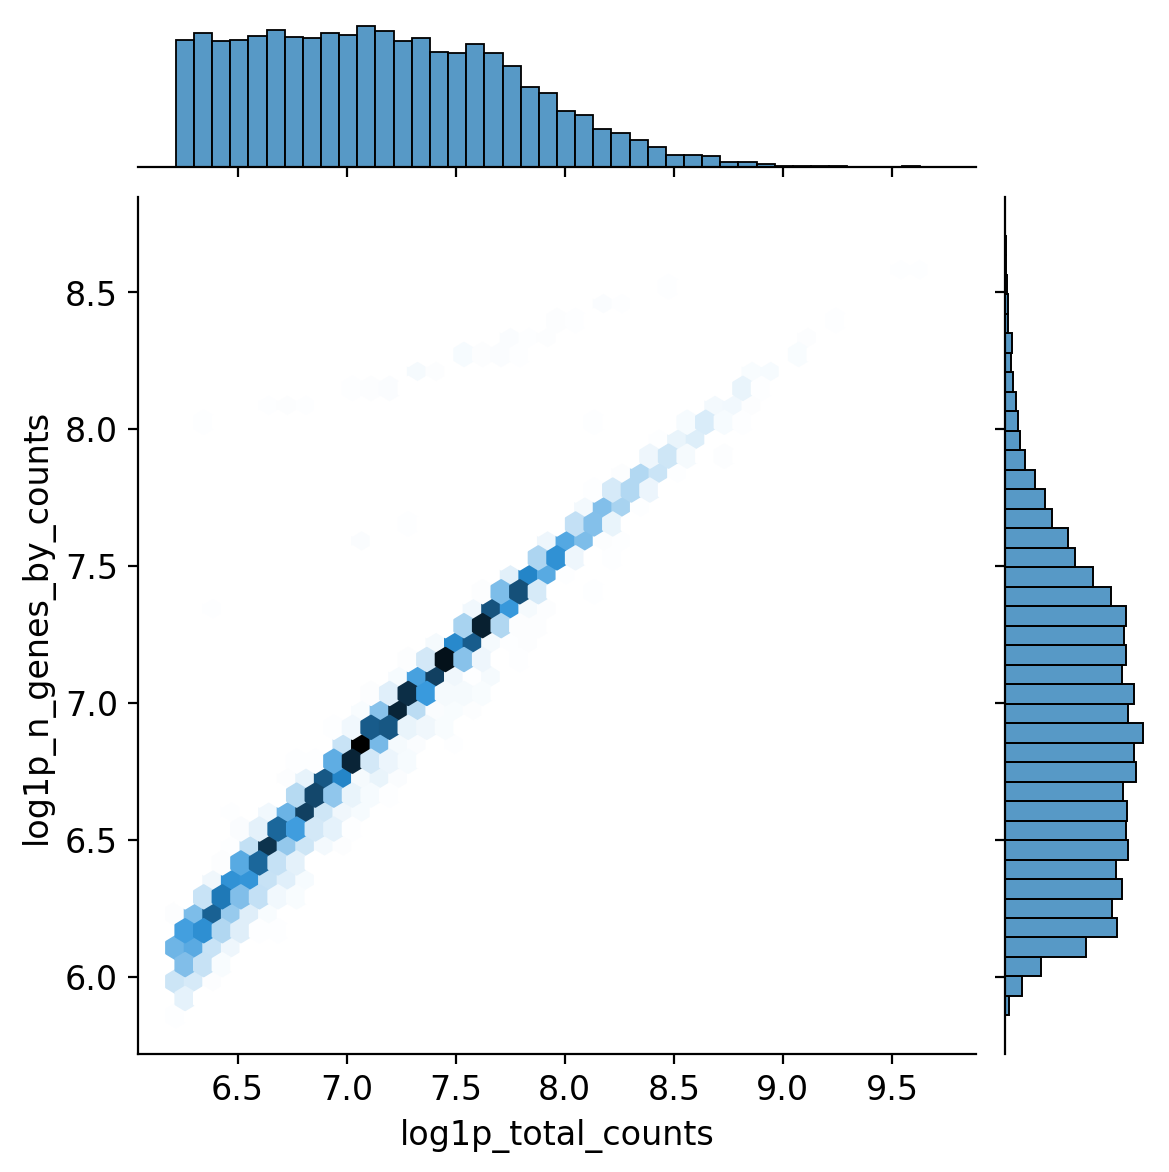

In [352]:
sns.jointplot(
    data=Oadata.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

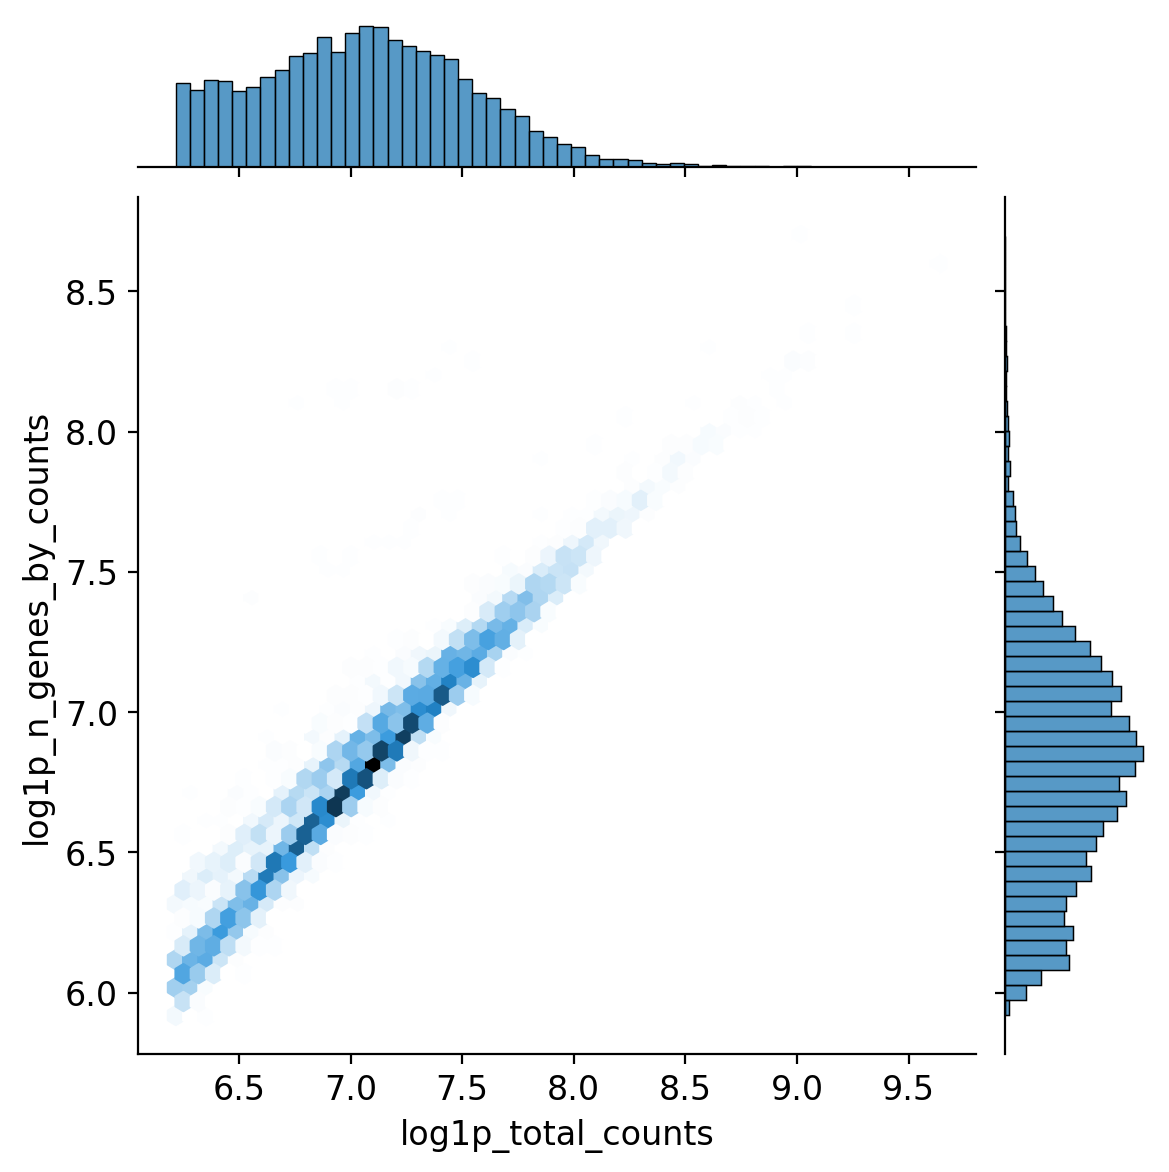

In [353]:
sns.jointplot(
    data=Tadata.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

In [354]:
#adata.obs_names_make_unique()
sc.pp.normalize_per_cell(Oadata, counts_per_cell_after=1e4)
sc.pp.log1p(Oadata)

#Iadata.obs_names_make_unique()
sc.pp.normalize_per_cell(Tadata, counts_per_cell_after=1e4)
sc.pp.log1p(Tadata)

In [355]:
intersect = [t for t in Oadata.obs["cell_identity"] if t in Tadata.obs["cell_identity"]]

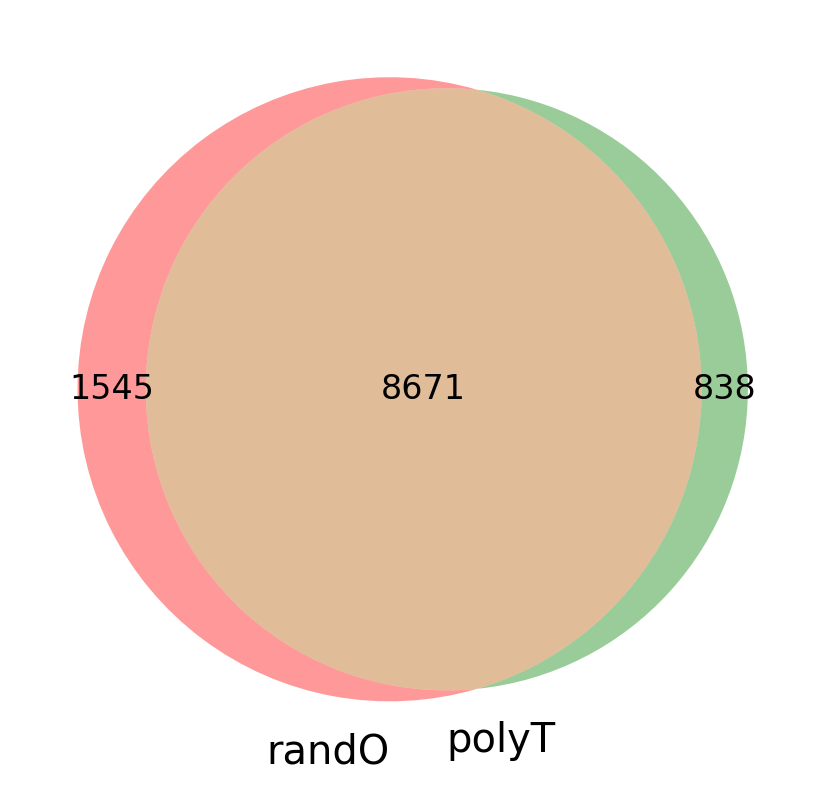

In [356]:
#!pip install matplotlib-venn
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

tadata = [t for t in Tadata.obs["cell_identity"]]
oadata = [o for o in Oadata.obs["cell_identity"]]

venn2((set(oadata), set(tadata)), ('randO', 'polyT'))


In [357]:
intersect_g = [gene for gene in Oadata.var.index if gene in Tadata.var.index]

In [358]:
intersect = set(tadata) & set(oadata)
print(len(intersect))
print(len(intersect_g))

8671
9766


In [359]:
Tadata.var.index

Index(['ENSMUSG00000051951.6', 'ENSMUSG00000103161.2', 'ENSMUSG00000033845.14',
       'ENSMUSG00000102275.2', 'ENSMUSG00000025903.15', 'ENSMUSG00000104217.2',
       'ENSMUSG00000033813.16', 'ENSMUSG00000002459.18',
       'ENSMUSG00000033793.13', 'ENSMUSG00000025905.15',
       ...
       'ENSMUSG00000068457.15', 'ENSMUSG00000069045.12',
       'ENSMUSG00000103234.2', 'ENSMUSG00000121561.1', 'ENSMUSG00000121544.1',
       'ENSMUSG00000121553.1', 'ENSMUSG00000121554.1', 'ENSMUSG00000099840.3',
       'ENSMUSG00000095134.3', 'ENSMUSG00000096768.9'],
      dtype='object', length=10916)

In [360]:
pearson_gene_O_vs_T = []
for c in intersect:
    if np.squeeze(np.asarray(Oadata[c, intersect_g].X.todense())).all() != 1:
        pearson=scipy.stats.pearsonr(np.squeeze(np.asarray(Oadata[c, intersect_g].X.todense())), np.squeeze(np.asarray(Tadata[c, intersect_g].X.todense())))
        pearson_gene_O_vs_T.append(pearson[0])

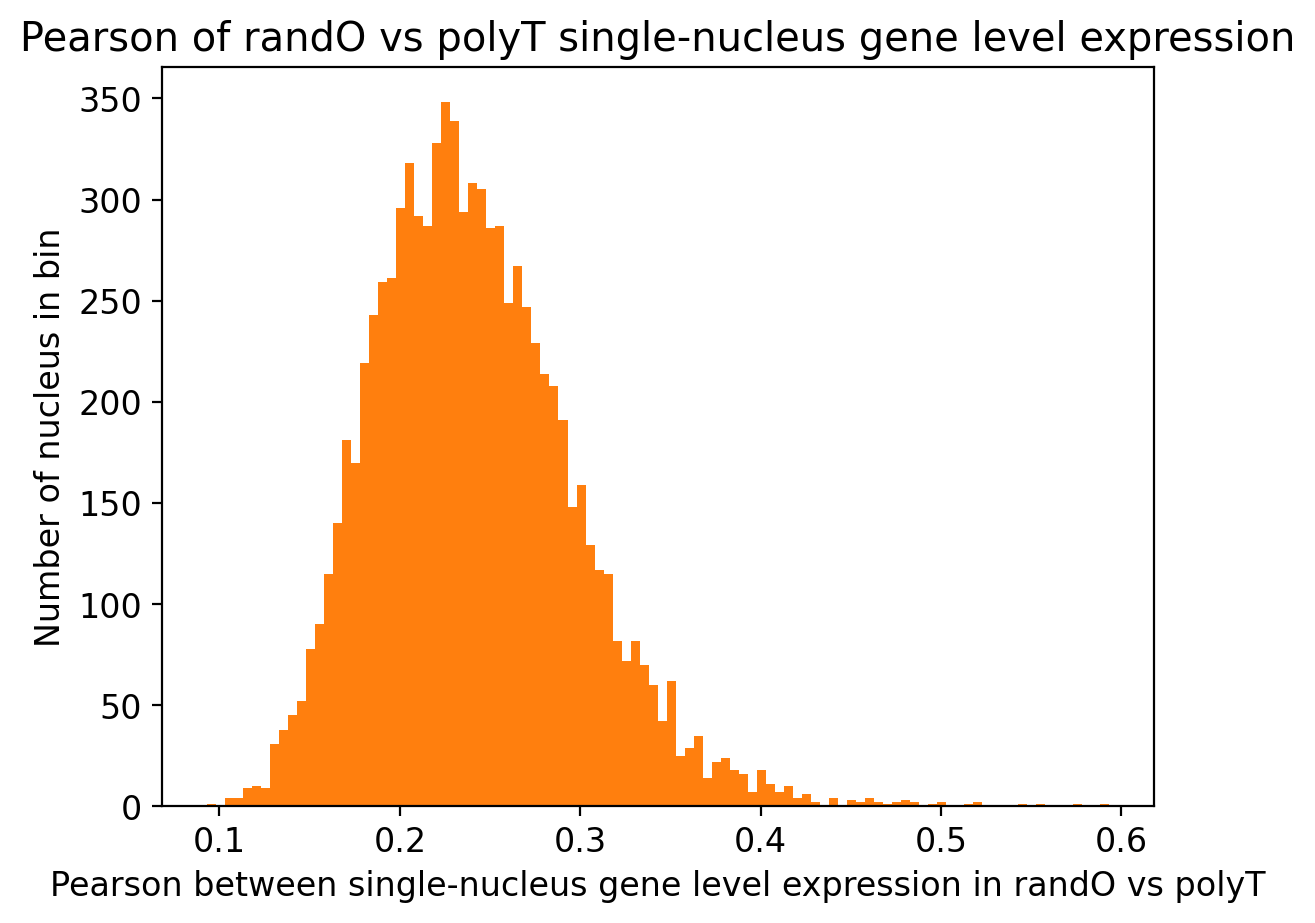

8671

In [361]:
import matplotlib.pyplot as plt

plt.hist(pearson_gene_O_vs_T, bins=100, color='C1')
plt.xlabel("Pearson between single-nucleus gene level expression in randO vs polyT")
plt.ylabel("Number of nucleus in bin")
plt.title("Pearson of randO vs polyT single-nucleus gene level expression")
plt.show()
len(pearson_gene_O_vs_T)

In [362]:
#Iadata.obs_names_make_unique(join='-')
spearman_gene_O_vs_T = []
for c in intersect:
    if np.squeeze(np.asarray(Oadata[c, intersect_g].X.todense())).all() != 1:
        spearman=scipy.stats.spearmanr(np.squeeze(np.asarray(Oadata[c, intersect_g].X.todense())), np.squeeze(np.asarray(Tadata[c, intersect_g].X.todense())))
        spearman_gene_O_vs_T.append(spearman[0])

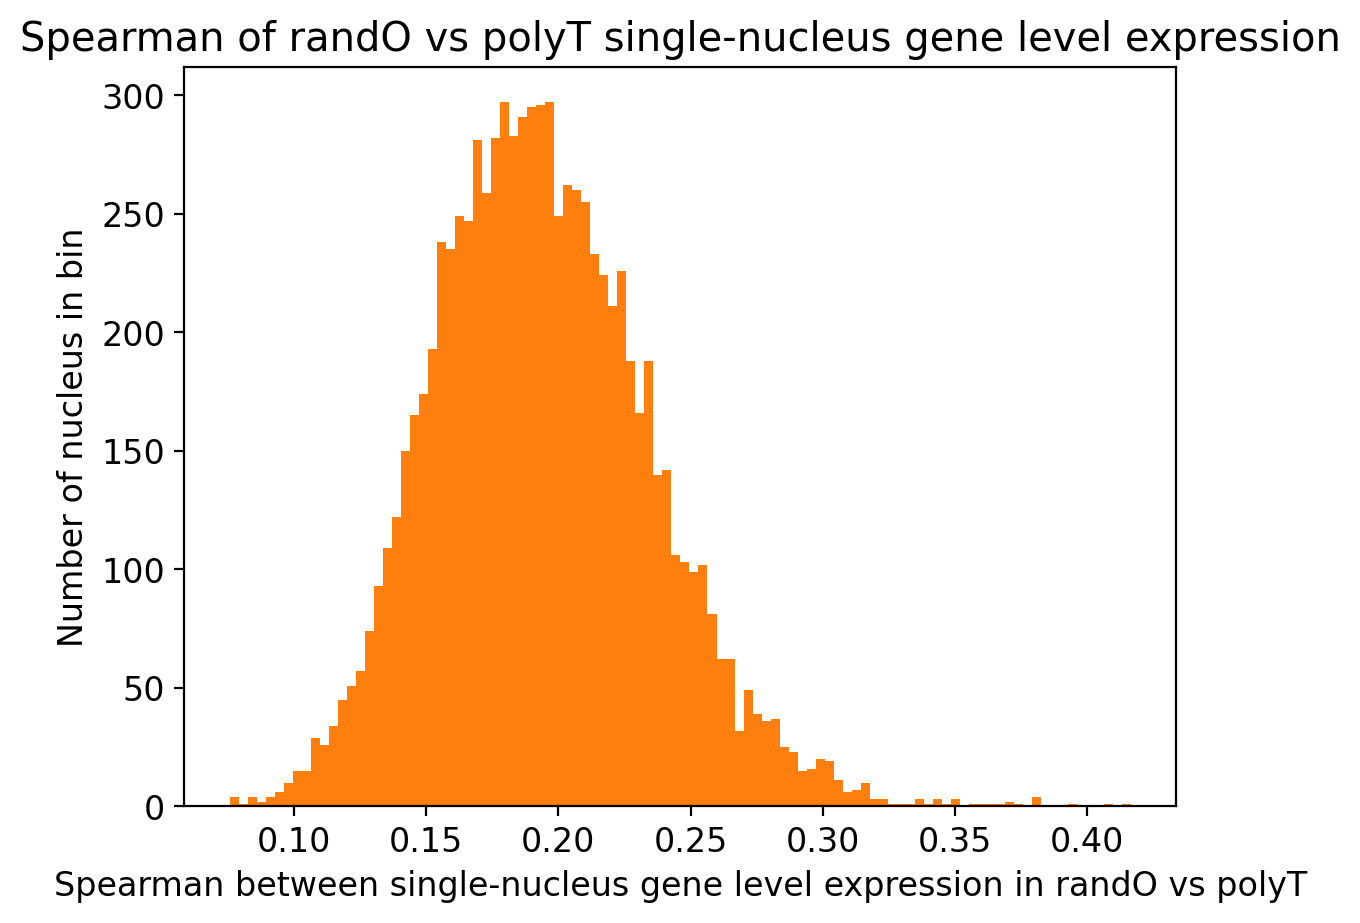

8671

In [363]:
import matplotlib.pyplot as plt

plt.hist(spearman_gene_O_vs_T, bins=100, color='C1')
plt.xlabel("Spearman between single-nucleus gene level expression in randO vs polyT")
plt.ylabel("Number of nucleus in bin")
plt.title("Spearman of randO vs polyT single-nucleus gene level expression")
plt.show()
len(spearman_gene_O_vs_T)

/tmp/ipykernel_103700/2198853509.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  plt.hexbin(Oadata.obs['n_counts'][intersect], spearman_gene_O_vs_T, gridsize=50, cmap='jet', bins='log')


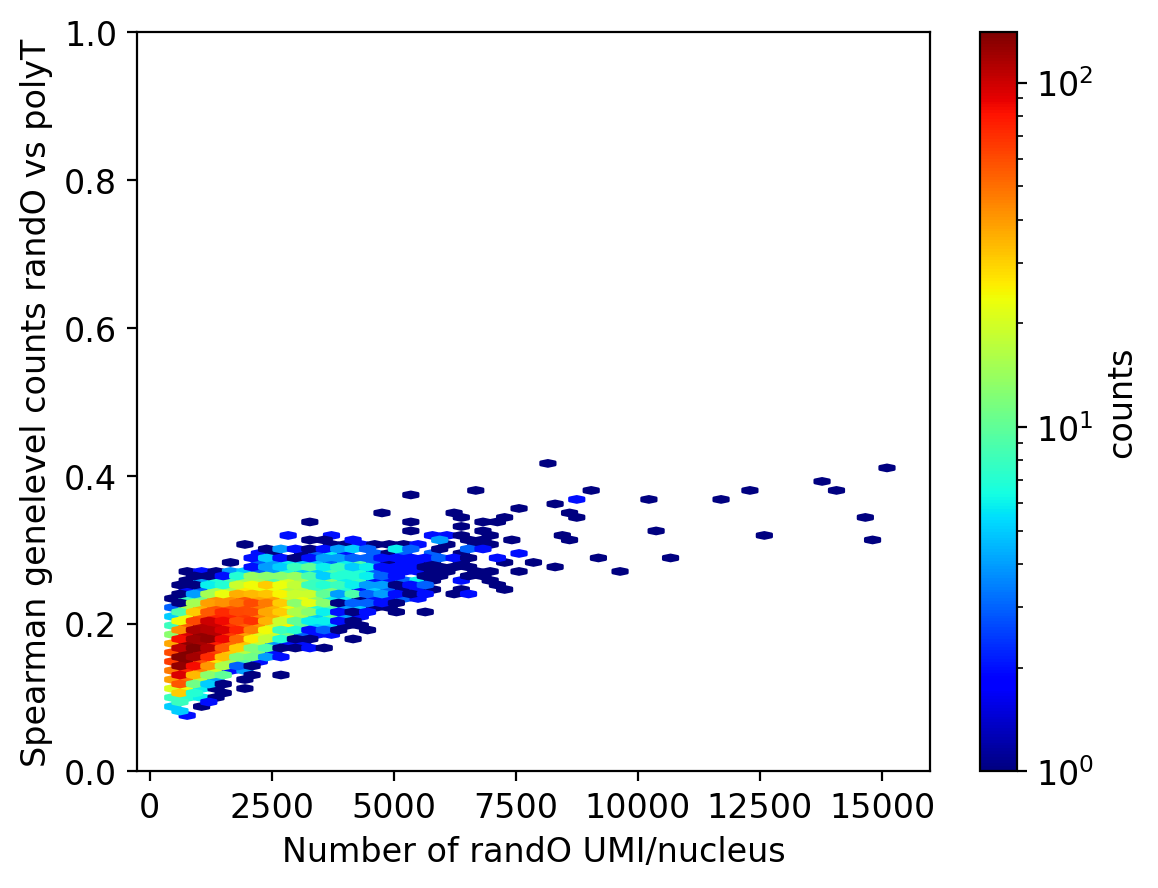

In [368]:
#plt.scatter(adata.obs['n_counts'], spearman_gene_ONT_vs_Ill)
plt.hexbin(Oadata.obs['n_counts'][intersect], spearman_gene_O_vs_T, gridsize=50, cmap='jet', bins='log')
plt.ylabel("Spearman genelevel counts randO vs polyT")
plt.xlabel("Number of randO UMI/nucleus")
plt.colorbar(label='counts')
plt.ylim((0,1))
plt.show()

/tmp/ipykernel_103700/4243745248.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  plt.hexbin(Tadata.obs['n_counts'][intersect], spearman_gene_O_vs_T, gridsize=50, cmap='jet', bins='log')


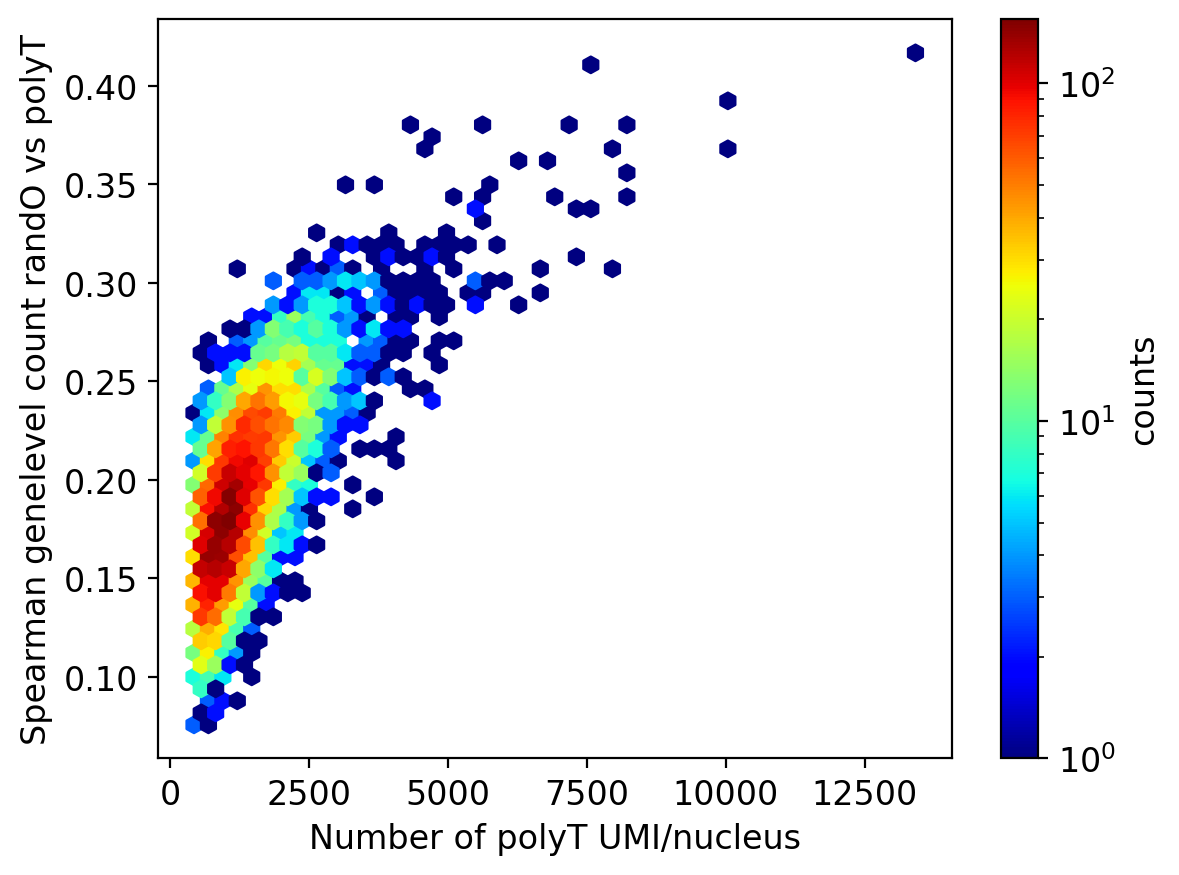

In [365]:
#plt.scatter(adata.obs['n_counts'], spearman_gene_ONT_vs_Ill)
plt.hexbin(Tadata.obs['n_counts'][intersect], spearman_gene_O_vs_T, gridsize=50, cmap='jet', bins='log')
plt.ylabel("Spearman genelevel count randO vs polyT")
plt.xlabel("Number of polyT UMI/nucleus")
plt.colorbar(label='counts')
plt.show()

/tmp/ipykernel_103700/1117531585.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  plt.hexbin(Oadata.obs['n_counts'][intersect], Tadata.obs['n_counts'][intersect], gridsize=50, cmap='jet', bins='log')
/tmp/ipykernel_103700/1117531585.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  plt.hexbin(Oadata.obs['n_counts'][intersect], Tadata.obs['n_counts'][intersect], gridsize=50, cmap='jet', bins='log')


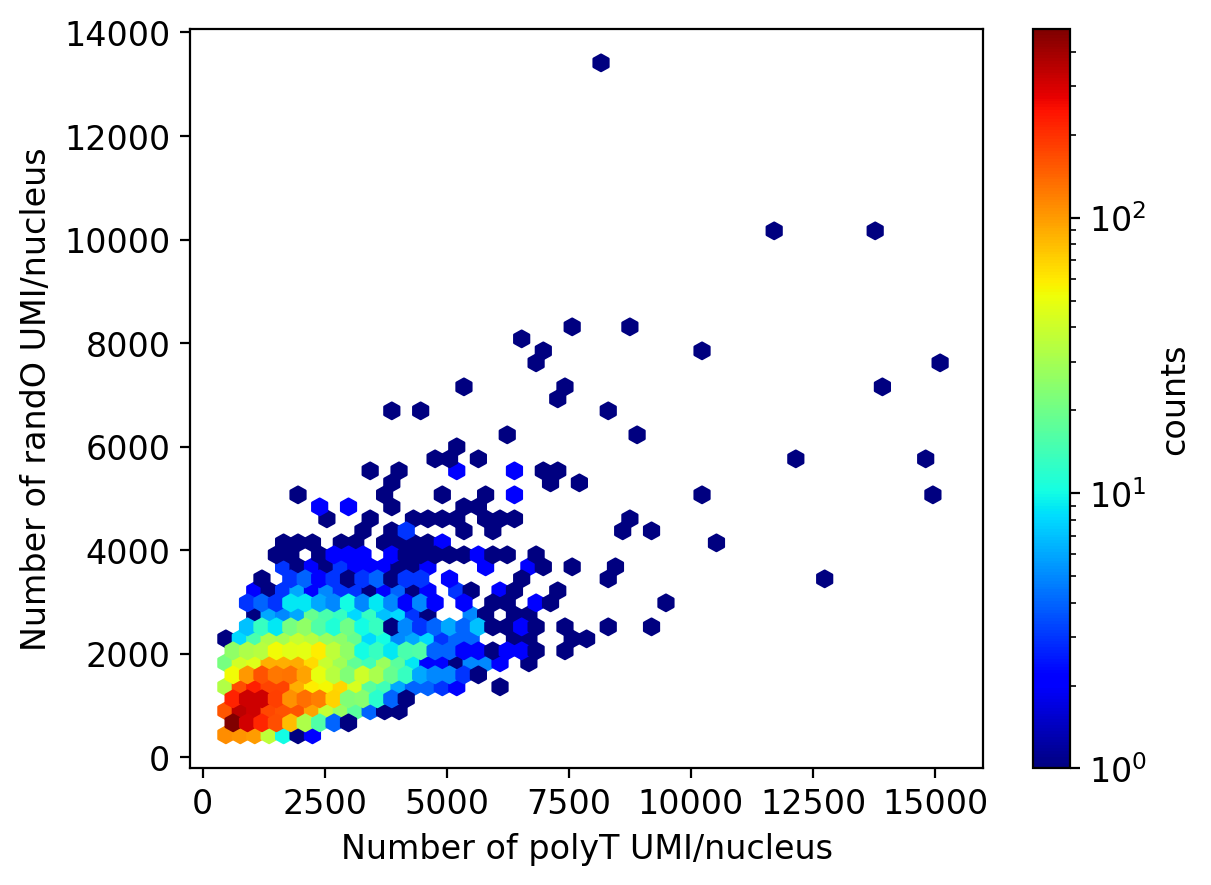

In [366]:
#plt.scatter(adata.obs['n_counts'], spearman_gene_ONT_vs_Ill)
plt.hexbin(Oadata.obs['n_counts'][intersect], Tadata.obs['n_counts'][intersect], gridsize=50, cmap='jet', bins='log')
plt.ylabel("Number of randO UMI/nucleus")
plt.xlabel("Number of polyT UMI/nucleus")
plt.colorbar(label='counts')
plt.show()

In [367]:
Oadata.obs.index

Index(['AAACATCGAACAACCA-B1', 'AAACATCGAACTCACC-C9', 'AAACATCGAACTCACC-C2',
       'AAACATCGAAGAGATC-C2', 'AAACATCGAAGGTACA-C1', 'AAACATCGAATCCGTC-C9',
       'AAACATCGAATCCGTC-C7', 'AAACATCGAATCCGTC-B9', 'AAACATCGAATGTTGC-A6',
       'AAACATCGACAAGCTA-D9',
       ...
       'TTCACGCAGCTAACGA-C6', 'TTCACGCAGGAGAACA-D2', 'TTCACGCAGGTGCGAA-D6',
       'TTCACGCATAGGATGA-C10', 'TTCACGCATATCAGCA-B4', 'TTCACGCATCCGTCTA-B5',
       'TTCACGCATCCGTCTA-C11', 'TTCACGCATCTTCACA-B2', 'TTCACGCATCTTCACA-D9',
       'TTCACGCATGAAGAGA-C10'],
      dtype='object', name='cell_identity', length=10216)